# Week 2 - Day 4: Exploratory Data Analysis (EDA)
This notebook performs a hands-on EDA on the music dataset.

**Step 1 — Load dataset**

We load `data.csv` from the notebook directory and remove the unnecessary `Unnamed: 0` index column if present.

In [1]:
import pandas as pd
df = pd.read_csv('data.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.shape

(2017, 16)

**Step 2 — Inspect the data**

Use `shape`, `head()`, `info()` and `describe()` to understand the dataset structure and basic statistics.

In [1]:
df.head()
df.info()
df.select_dtypes(include=['number']).describe()

Shape: (2017, 16)


Columns: ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'target', 'song_title', 'artist']


Head:
   acousticness  danceability  duration_ms  energy  instrumentalness  key  liveness  loudness  mode  speechiness    tempo  time_signature  valence  target      song_title            artist
0        0.0102         0.833       204600   0.434          0.021900    2    0.1650    -8.795     1       0.4310  150.062             4.0    0.286       1        Mask Off            Future
1        0.1990         0.743       326933   0.359          0.006110    1    0.1370   -10.401     1       0.0794  160.083             4.0    0.588       1         Redbone  Childish Gambino
2        0.0344         0.838       185707   0.412          0.000234    2    0.1590    -7.148     1       0.2890   75.044             4.0    0.173       1    Xanny Family            Future
3        0.6040         0.494       199413   0.338          0.510000    5    0.0922   -15.236     1       0.0261   86.468             4.0    0.230       1  Master Of None       Beach House
4        0.1800         0.678       392893   0.56

Info:
<class 'pandas.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      2017 non-null   float64
 1   danceability      2017 non-null   float64
 2   duration_ms       2017 non-null   int64  
 3   energy            2017 non-null   float64
 4   instrumentalness  2017 non-null   float64
 5   key               2017 non-null   int64  
 6   liveness          2017 non-null   float64
 7   loudness          2017 non-null   float64
 8   mode              2017 non-null   int64  
 9   speechiness       2017 non-null   float64
 10  tempo             2017 non-null   float64
 11  time_signature    2017 non-null   float64
 12  valence           2017 non-null   float64
 13  target            2017 non-null   int64  
 14  song_title        2017 non-null   str    
 15  artist            2017 non-null   str    
dtypes: float64(10), int64(4), str(2)
memory usage: 

Describe:
       acousticness  danceability   duration_ms       energy  instrumentalness          key     liveness     loudness         mode  speechiness        tempo  time_signature      valence       target
count   2017.000000   2017.000000  2.017000e+03  2017.000000       2017.000000  2017.000000  2017.000000  2017.000000  2017.000000  2017.000000  2017.000000     2017.000000  2017.000000  2017.000000
mean       0.187590      0.618422  2.463062e+05     0.681577          0.133286     5.342588     0.190844    -7.085624     0.612295     0.092664   121.603272        3.968270     0.496815     0.505702
std        0.259989      0.161029  8.198181e+04     0.210273          0.273162     3.648240     0.155453     3.761684     0.487347     0.089931    26.685604        0.255853     0.247195     0.500091
min        0.000003      0.122000  1.604200e+04     0.014800          0.000000     0.000000     0.018800   -33.097000     0.000000     0.023100    47.859000        1.000000     0.034800     0.00

**Step 3 — Missing values & duplicates**

Check missing values and duplicates, then visualize `target` distribution with a count plot to inspect class balance.

In [1]:
df.isnull().sum()
df.duplicated().sum()

Missing values:
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
target              0
song_title          0
artist              0


Duplicate rows: 5


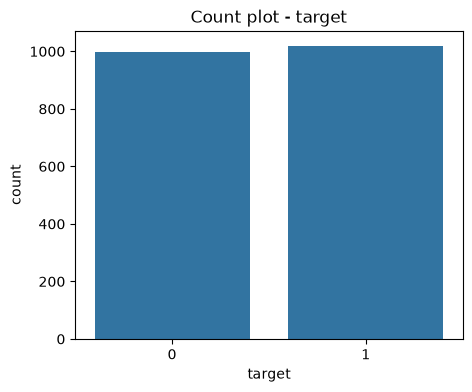

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='target', data=df)
plt.title('Count plot - target')
plt.show()

**Result — target distribution**

The target class counts are: {1: 1020, 0: 997}. This indicates the classes are nearly balanced (1020 vs 997), so no immediate need for oversampling or undersampling.

**Univariate analysis — Histograms**

Plot histograms for selected numeric features to inspect distributions and skewness.

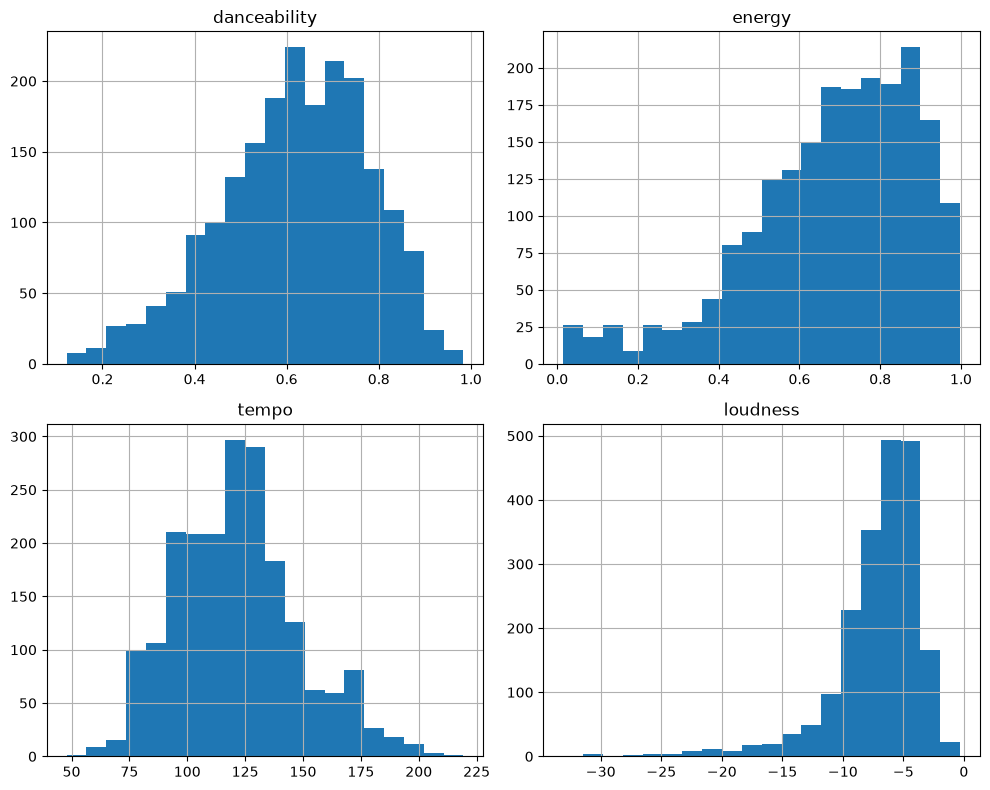

In [13]:
df[['danceability','energy','tempo','loudness']].hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()

**Result — histograms**

Observations: describe distributions concisely for each feature.

**Outliers — Boxplot and IQR (tempo)**

Use a boxplot to visualize outliers for `tempo` and compute IQR-based bounds.

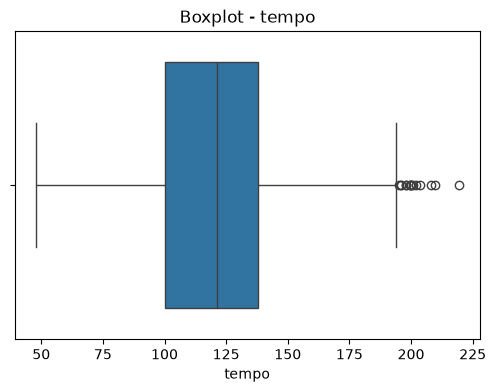

In [1]:
sns.boxplot(x=df['tempo'])
plt.title('Boxplot - tempo')
plt.show()

In [1]:
q1 = df['tempo'].quantile(0.25)
q3 = df['tempo'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
outliers = df[(df['tempo']<lower)|(df['tempo']>upper)]
len(outliers)

Q1: 100.189
Q3: 137.849
IQR: 37.66
Lower bound: 43.699
Upper bound: 194.339
Number of outliers: 15


Outliers (head):
     acousticness  danceability  duration_ms  energy  instrumentalness  key  liveness  loudness  mode  speechiness    tempo  time_signature  valence  target        song_title       artist
102        0.2470         0.525       292760   0.643          0.000000    5    0.1060    -6.874     0       0.8160  199.727             4.0    0.943       1    Willing & Able   Disclosure
124        0.6740         0.462       226333   0.449          0.000632    0    0.0993    -9.271     0       0.0916  209.686             4.0    0.748       1  Danger and Dread   Brown Bird
348        0.1330         0.402       206920   0.794          0.000000   11    0.1330    -3.982     0       0.1250  195.058             3.0    0.706       1          Powerful  Major Lazer
412        0.0106         0.346       301867   0.808          0.685000   11    0.2470    -5.791     0       0.0302  219.331             4.0    0.711       1            Lazuli  Beach House
414        0.1950         0.605       20957

**Decision on tempo outliers**

The tempo outliers were detected using the IQR method. They will not be removed because they may represent valid songs with unusually low or high tempo values rather than measurement errors.

**Bivariate analysis — Energy vs Loudness**

We plot `energy` against `loudness` and add a regression line to assess linear relationship and strength.

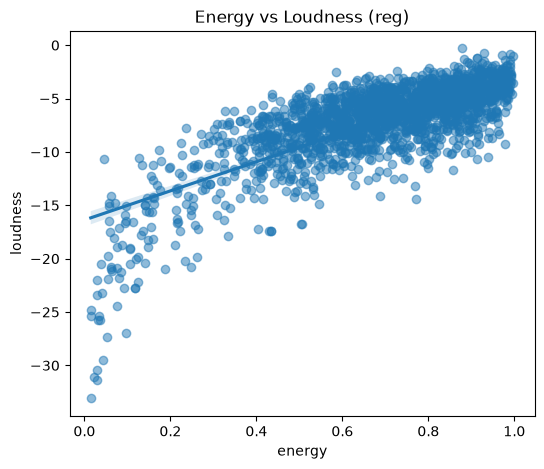

In [1]:
sns.regplot(data=df, x='energy', y='loudness', scatter_kws={'alpha':0.5})
plt.title('Energy vs Loudness')
plt.show()

**Result — Energy vs Loudness**

There is a relatively strong positive correlation between `energy` and `loudness` (correlation ≈ 0.76), meaning higher energy tracks tend to be louder.

**Multivariate analysis — Correlation heatmap**

Compute correlation on numeric features and display a heatmap.

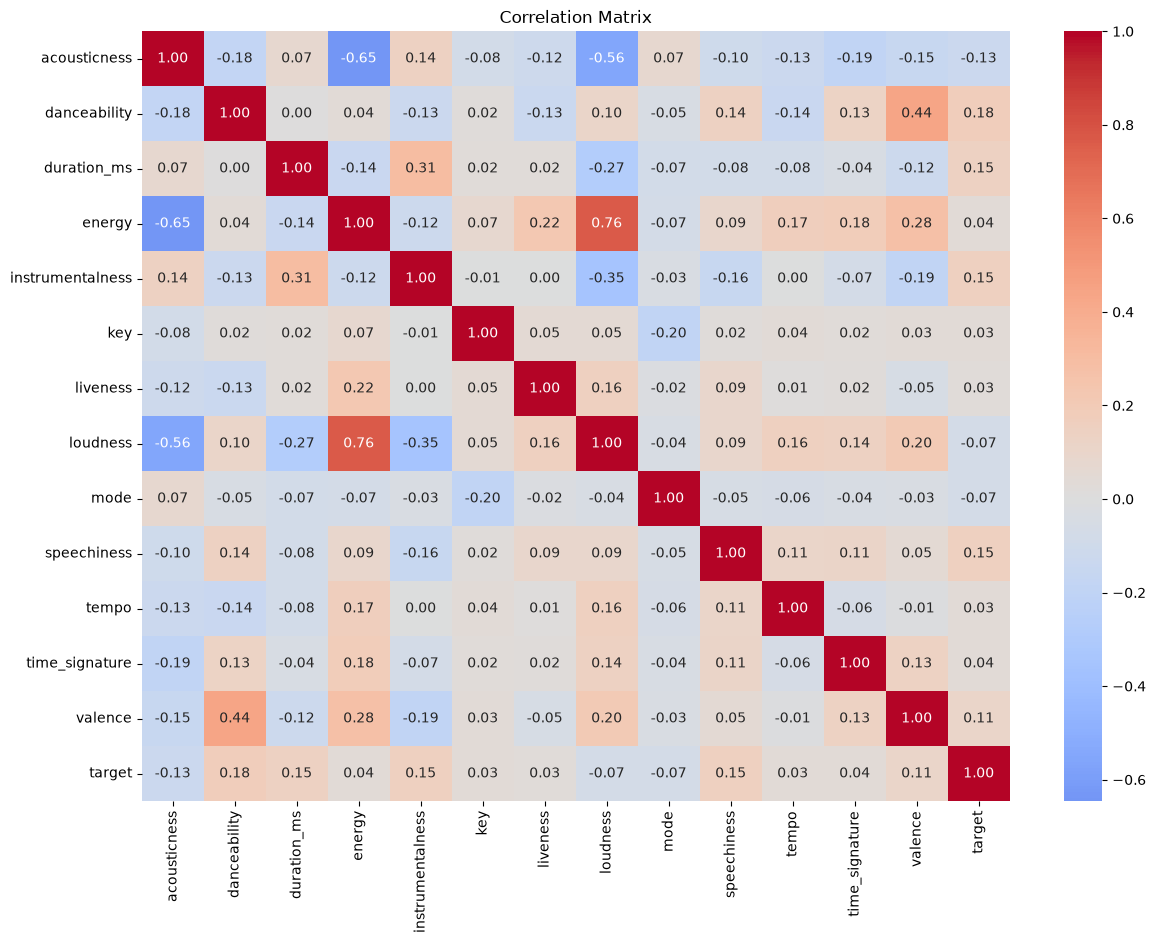

In [1]:
numeric_df = df.select_dtypes(include='number')
numeric_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Result — Correlation highlights**

- `energy` and `loudness` show a strong positive correlation (~0.76).
- Review other correlation pairs in the heatmap for modeling considerations.

## Final EDA Conclusions

- The dataset contains 2017 rows and 16 columns after removing the index column.
- There are no missing values.
- There are no duplicated rows.
- The target classes are nearly balanced: {1: 1020, 0: 997}.
- Tempo has 15 detected outliers by IQR; we keep them as valid observations.
- `energy` and `loudness` show a strong positive correlation (~0.76).

The dataset is suitable for further analysis and modeling without immediate need for missing-value or duplicate handling.